## Part 1: Environment Setup and Validation
### 1.1 Installation

In [3]:
%pip install opencv-python
%pip install matplotlib
%pip install numpy pandas

### 1.2 Import & Validate

OpenCV OK:  True


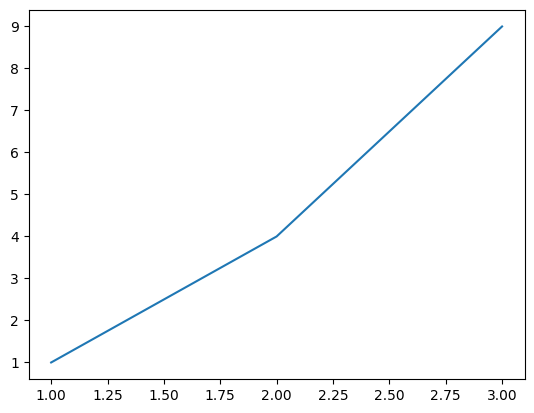

Matplotlib OK: plot displayed above


In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

img = np.zeros((10,10,3), dtype=np.uint8)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print("OpenCV OK: ", gray.shape == (10, 10))
plt.plot([1,2,3], [1,4,9])
plt.show()
print("Matplotlib OK: plot displayed above")

## Part 2: Python Data structures & Logic
### Task 1: Object-Oriented Grocery Manager

In [14]:
class GroceryManager:
  def __init__(self):
    self.items = {}

  def view_list(self):
    if not self.items:
      print("Grocery list is empty.")
      return
    print("\n--- Grocery List ---")
    for item, details in self.items.items():
      print(f"{item}: {details["quantity"]} x ${details["price"]:.2f}")
    print("--------------------\n")

  def calculate_total(self):
    total = sum(details["quantity"] * details["price"] for details in self.items.values())
    print(f"Total cost: ${total:.2f}")
    return total

  def add_item(self, item, quantity, price):
    if item in self.items: #if already exists then update the quantity
      self.items[item]["quantity"] += quantity
    else:
      self.items[item] = {"quantity":quantity, "price": price}
    print(f"Added {quantity} x {item} at ${price:.2f} each.")

  def remove_item(self, item):
    if item not in self.items:
      print(f"Error: '{item}' not found in the grocery list.")
      return

    del self.items[item]
    print(f"Removed {item} from the grocery list.")

In [15]:
manager = GroceryManager()
manager.add_item("apples", 3, 0.5)
manager.add_item("banana", 5, 0.75)
manager.view_list()
manager.calculate_total()
manager.remove_item("bread")
manager.remove_item("banana")
manager.view_list()

Added 3 x apples at $0.50 each.
Added 5 x banana at $0.75 each.

--- Grocery List ---
apples: 3 x $0.50
banana: 5 x $0.75
--------------------

Total cost: $5.25
Error: 'bread' not found in the grocery list.
Removed banana from the grocery list.

--- Grocery List ---
apples: 3 x $0.50
--------------------



### Task 2: Advanced Student Record System

In [16]:
students = {
    101: {"Name": "Ali", "Major": "CS", "Grades": [85, 90, 78]},
    102: {"Name": "Sara", "Major": "Math", "Grades": [92, 88, 95]},
    103: {"Name": "Bilal", "Major": "CS", "Grades": [70, 65, 80]},
    104: {"Name": "Ayesha", "Major": "Physics", "Grades": [88, 91, 84, 79]},
    105: {"Name": "Hamza", "Major": "Math", "Grades": [60, 72, 68]},
    106: {"Name": "Zara", "Major": "CS", "Grades": [95, 98, 92]},
    107: {"Name": "Usman", "Major": "Physics", "Grades": [55, 60, 58]},
    108: {"Name": "Fatima", "Major": "Biology", "Grades": [82, 85]},
    109: {"Name": "Omar", "Major": "Biology", "Grades": [77, 80, 74, 90]},
    110: {"Name": "Noor", "Major": "Math", "Grades": [99, 100, 97]},
}

In [27]:
def top_student(records):
  if not records:
    print(f"No records found.\nEmpty dictionary.\n")
    return
  best_name = None
  best_avg = -1
  for id, details in records.items():
    name = details["Name"]
    grades = details["Grades"]
    if not grades:
      print(f"No grades found for {name}.")
      continue
    avg = sum(grades)/ len(grades)
    if avg > best_avg:
      best_avg = avg
      best_name = name
  if best_name is not None:
    print(f"The best student is {best_name} with an average grade of {best_avg:.2f}.\n")
  else:
    print("No students with grades found.\n")

def search_students(records, major):
  target = major.strip().lower()
  matches = [details for details in records.values() if details["Major"].strip().lower() == target]
  if not matches:
    print(f"\nNo students found in the '{major}' major.")
    return
  print(f"Students in the '{major}' major:")
  for details in matches:
    grade = sum(details["Grades"])/len(details["Grades"]) if details["Grades"] else 0
    print(f"Name: {details['Name']}, Avg Grade: {grade:.2f}")


In [28]:
top_student(students)
search_students(students, "CS")
search_students(students, "Artificial Intelligence")

The best student is Noor with an average grade of 98.67.

Students in the 'CS' major:
Name: Ali, Avg Grade: 84.33
Name: Bilal, Avg Grade: 71.67
Name: Zara, Avg Grade: 95.00

No students found in the 'Artificial Intelligence' major.


## Part 3: Core Computer Vision & Matplotlib
### Task 3: Safe Image Loading & RGB Visualization

In [7]:
from google.colab import files
sukuna = files.upload()

Saving sukuna.jpg to sukuna (1).jpg


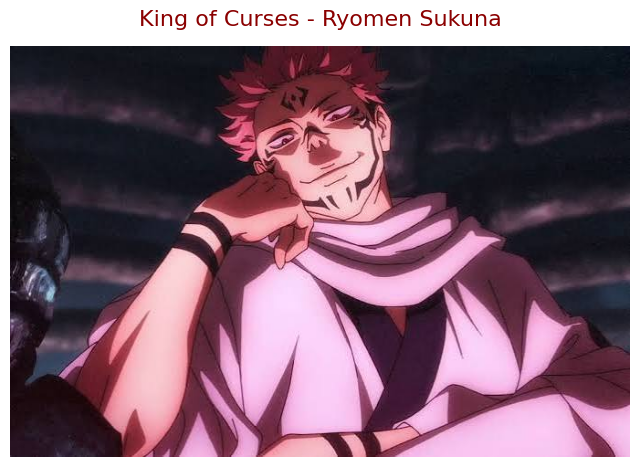

In [9]:
image = list(sukuna.keys())[0]
sukuna_image = cv2.imread(image)
if sukuna_image is None:
  print(f"Error: Image not found.")
else:
  sukuna_rgb = cv2.cvtColor(sukuna_image, cv2.COLOR_BGR2RGB)
  plt.figure(figsize=(8,6))
  plt.axis("off")
  plt.title("King of Curses - Ryomen Sukuna", fontsize=16, color="darkred", pad=15)
  plt.imshow(sukuna_rgb)
  plt.show()

### Task 4: Interactive Geometry & Blank Canvas

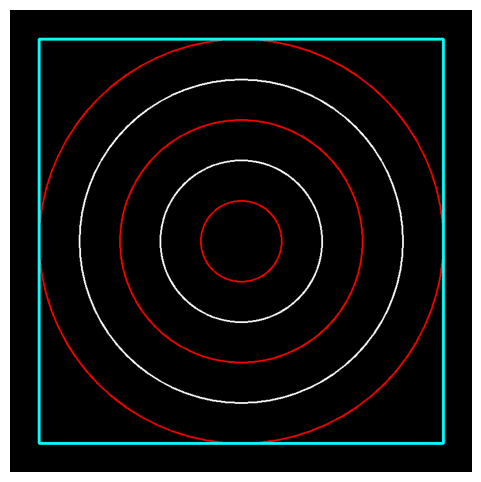

In [12]:
canvas = np.zeros((800, 800, 3), dtype=np.uint8) #np.zeroes((height, width, channel))
height, width = canvas.shape[:2]
center = (width // 2, height // 2)
radii = [350, 280, 210, 140, 70] #outer to inner
colors = [(0,0,255), (255,255,255), (0,0,255), (255,255,255), (0,0,255)] #red and white
for radius, color in zip(radii, colors):
  cv2.circle(canvas, center, radius, color, 2)
top_left = (center[0] - radii[0], center[1]-radii[0])
bottom_right = (center[0] + radii[0], center[1]+radii[0])
cv2.rectangle(canvas, top_left, bottom_right, (255,255,0), 3)
canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,6))
plt.imshow(canvas_rgb)
plt.axis("off")
plt.show()

### Task 5: Advanced Blurring & NumPy ROI Extraction

In [13]:
from google.colab import files
sukuna = files.upload()
image = list(sukuna.keys())[0]
sukuna_image = cv2.imread(image)
if sukuna_image is None:
  print(f"Error: Image not found.")
else:
  original_img = cv2.cvtColor(sukuna_image, cv2.COLOR_BGR2RGB)

Saving sukuna.jpg to sukuna (2).jpg


In [18]:
blurred_img = cv2.GaussianBlur(original_img, (25,25), 0)

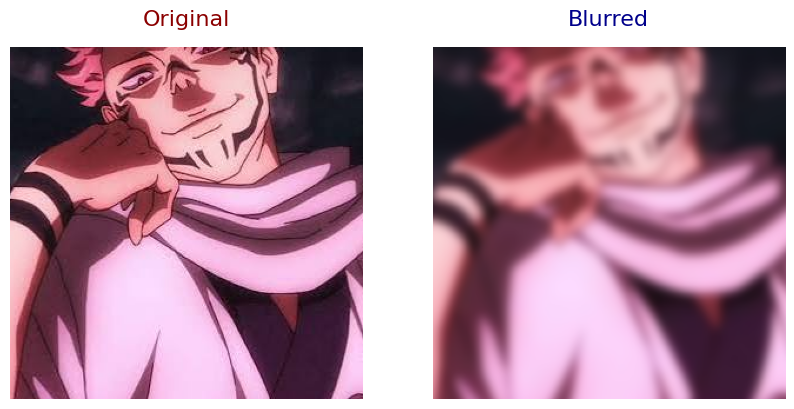

In [19]:
h, w = original_img.shape[: 2]
cy, cx = h//2, w//2
half = 150
roi_original = original_img[cy-half: cy+half, cx-half:cx+half]
roi_blurred = blurred_img[cy-half: cy+half, cx-half:cx+half]

fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].imshow(roi_original)
axes[0].axis("off")
axes[0].set_title("Original", fontsize=16, color="darkred", pad=15)
axes[1].imshow(roi_blurred)
axes[1].axis("off")
axes[1].set_title("Blurred", fontsize=16, color="darkblue", pad=15)
plt.show()

### Task 6: Alpha Blending & Typography

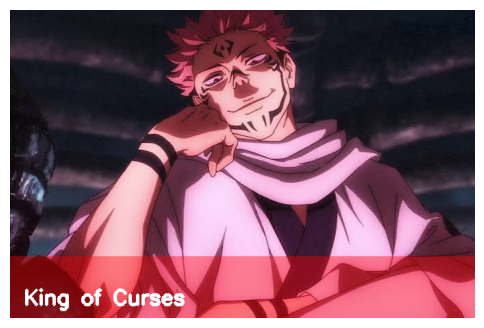

In [25]:
h, w = sukuna_image.shape[:2]
overlay = sukuna_image.copy()

y_start = int(h*0.8)
cv2.rectangle(overlay, (0,y_start), (w,h), (0, 0, 255), -1)
alpha = 0.4
blended = cv2.addWeighted(overlay, alpha, sukuna_image, 1-alpha, 0)
text = "King of Curses"
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(blended, text, (20, h-20), font, 1, (255,255,255), 3)
blended_rgb = cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,6))
plt.imshow(blended_rgb)
plt.axis("off")
plt.show()

### Task 7: Matrix-Based Rotation & Adaptive Thresholding

In [26]:
gray_image = cv2.cvtColor(sukuna_image, cv2.COLOR_BGR2GRAY)

#global binary thresholding
_, global_thresh = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)

#adaptive thresholding
adaptive_thresh = cv2.adaptiveThreshold(gray_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

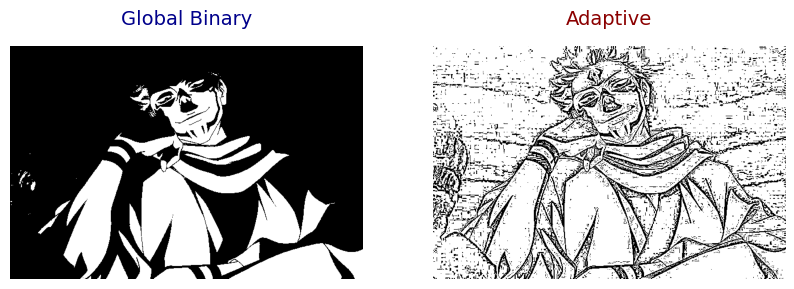

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(global_thresh, cmap='gray')
axes[0].axis('off')
axes[0].set_title("Global Binary", fontsize=14, color='darkblue', pad=15)

axes[1].imshow(adaptive_thresh, cmap='gray')
axes[1].axis('off')
axes[1].set_title("Adaptive", fontsize=14, color='darkred', pad=15)

plt.show()

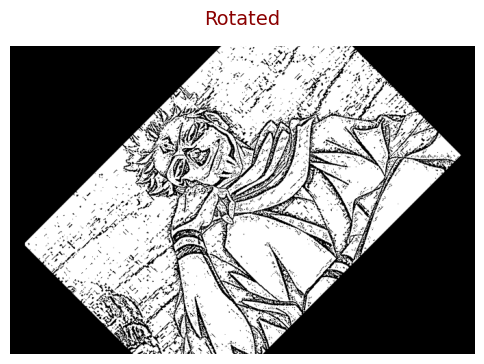

In [30]:
h, w = adaptive_thresh.shape[:2]
center=(w//2, h//2)
rotation_matrix = cv2.getRotationMatrix2D(center, 45, 0.8)
rotated = cv2.warpAffine(adaptive_thresh, rotation_matrix, (w,h)) #function that actually performs rotation

plt.figure(figsize=(6, 6))
plt.axis("off")
plt.imshow(rotated, cmap="gray")
plt.title("Rotated", fontsize=14, color='darkred', pad=15)
plt.show()


### Task 8: Masking with Bitwise Logic

In [31]:
from google.colab import files
sukuna = files.upload()
sukuna_img = list(sukuna.keys())[0]
gojo = files.upload()
gojo_img = list(gojo.keys())[0]

Saving sukuna.jpg to sukuna (3).jpg


Saving gojo.jpg to gojo.jpg


In [32]:
img1 = cv2.imread(sukuna_img)
img2 = cv2.imread(gojo_img)

img1 = cv2.resize(img1, (500, 500))
img2 = cv2.resize(img2, (500, 500))

mask = np.zeros((500, 500), dtype=np.uint8)
center = (250, 250)
radius = 150
cv2.circle(mask, center, radius, 255, -1) #white filled circle

#cut the circle shape out of image1 using the mask
img1_circle = cv2.bitwise_and(img1, img1, mask=mask)

#inverting the mask
mask_inv = cv2.bitwise_not(mask)

#cutting everything except the circle from the image2
img2_background = cv2.bitwise_and(img2, img2, mask=mask_inv)

result = cv2.bitwise_or(img1_circle, img2_background)

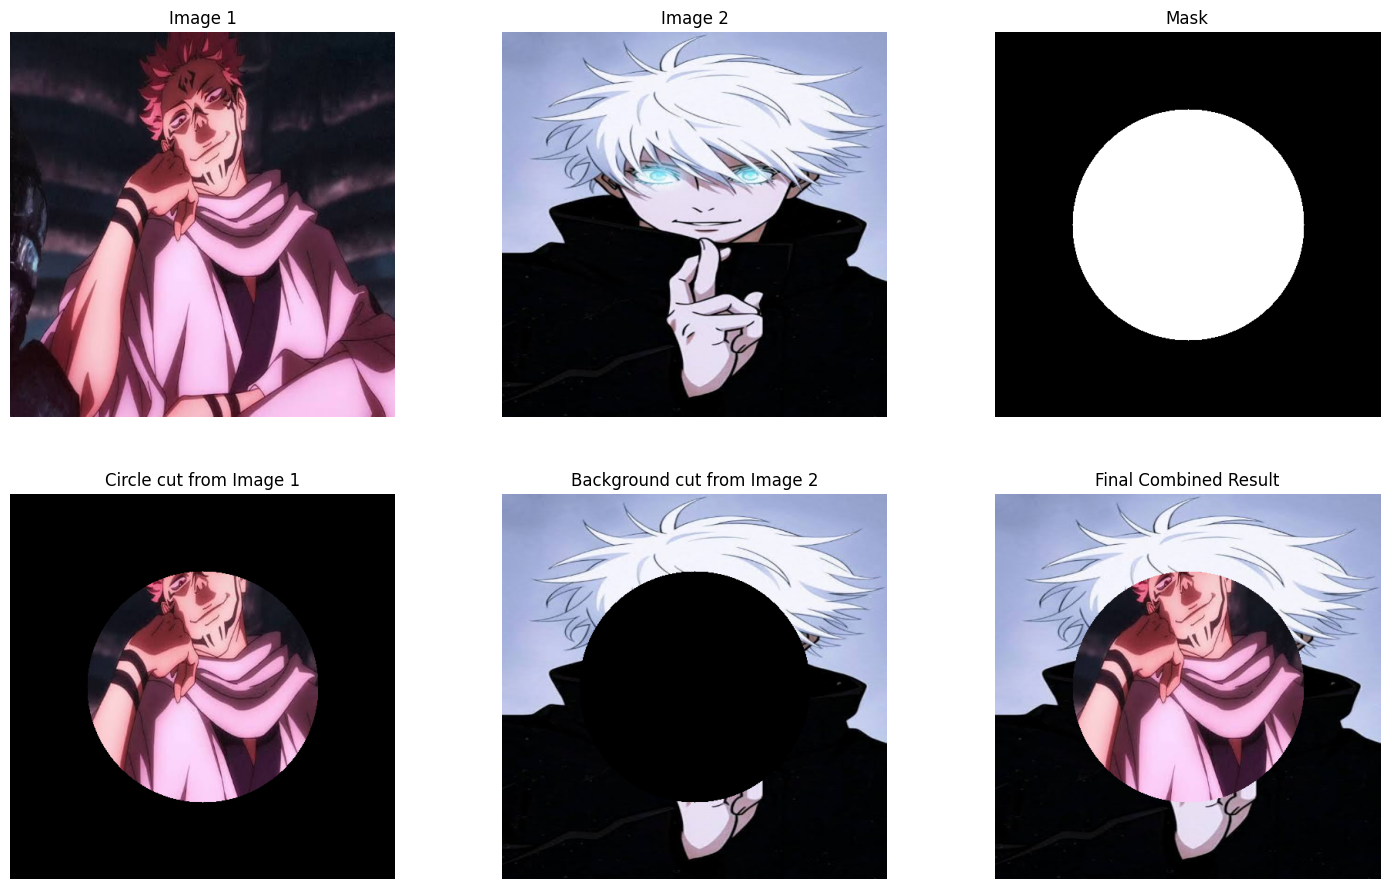

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

axes[0,0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
axes[0,0].set_title("Image 1")
axes[0,0].axis("off")

axes[0,1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[0,1].set_title("Image 2")
axes[0,1].axis("off")

axes[0,2].imshow(mask, cmap="gray")
axes[0,2].set_title("Mask")
axes[0,2].axis("off")

axes[1,0].imshow(cv2.cvtColor(img1_circle, cv2.COLOR_BGR2RGB))
axes[1,0].set_title("Circle cut from Image 1")
axes[1,0].axis("off")

axes[1,1].imshow(cv2.cvtColor(img2_background, cv2.COLOR_BGR2RGB))
axes[1,1].set_title("Background cut from Image 2")
axes[1,1].axis("off")

axes[1,2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[1,2].set_title("Final Combined Result")
axes[1,2].axis("off")

plt.show()

### Task 9: Statistical Image Profiling with Pandas

In [44]:
image = sukuna_image.reshape(-1, 3)
image_df = pd.DataFrame(image, columns=["Blue", "Green", "Red"])
image_df.head()

,Blue,Green,Red
0,23,14,11
1,24,15,12
2,26,17,14
3,29,20,17
4,32,23,20


In [45]:
image_df.describe()

,Blue,Green,Red
count,305550.000000,305550.000000,305550.000000
mean,94.397565,75.397732,110.051402
std,78.736403,69.370968,90.982901
min,0.000000,0.000000,0.000000
25%,33.000000,23.000000,26.000000
50%,56.000000,40.000000,81.000000
75%,173.000000,151.000000,229.000000
max,255.000000,238.000000,255.000000
